In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
folder_path = "../results/metrics"

In [4]:
video_severity = {
    "metrics_1": "moderate",
    "metrics_2": "severe",
    "metrics_3": "severe",
    "metrics_4": "severe",
    "metrics_5": "severe",
    "metrics_6": "severe",
    "metrics_7": "severe",
    "metrics_8": "severe",
    "metrics_9": "mild",
    "metrics_10": "moderate",
    "metrics_11": "moderate",
    "metrics_12": "severe",
    "metrics_13": "moderate"
}

In [5]:
all_metrics = []
for filename in os.listdir(folder_path):
    if filename.endswith(".csv") and filename.startswith("metrics_"):
        file_id = filename.split(".")[0]  # e.g., 'metrics_1'
        severity = video_severity.get(file_id, "unknown")
        df = pd.read_csv(os.path.join(folder_path, filename))
        df["Video"] = file_id
        df["Severity"] = severity
        all_metrics.append(df)

In [6]:
df_all = pd.concat(all_metrics, ignore_index=True)

In [7]:
df_long = df_all.melt(
    id_vars=["Video", "Metric", "Severity"],
    value_vars=["Raw", "Cleaned", "No Fillers"],
    var_name="Version",
    value_name="Score"
)

In [8]:
grouped_avg = df_long.groupby(["Severity", "Metric", "Version"]).mean(numeric_only=True).reset_index()


In [9]:
summary_table = grouped_avg.pivot_table(
    index=["Metric", "Version"],
    columns="Severity",
    values="Score"
)

In [21]:
print("Average Metrics by Severity:")
display(summary_table)  # or just: summary_table.head()

Average Metrics by Severity:


Severity                             mild  moderate    severe
Metric                  Version                              
BERTScore F1            Cleaned     0.658   0.53050  0.421625
                        No Fillers  0.880   0.78775  0.484375
                        Raw         0.685   0.43475  0.283250
BERTScore Precision     Cleaned     0.743   0.67725  0.490250
                        No Fillers  0.886   0.81825  0.521000
                        Raw         0.773   0.56775  0.363000
BERTScore Recall        Cleaned     0.573   0.39700  0.355750
                        No Fillers  0.874   0.75700  0.448500
                        Raw         0.599   0.30925  0.207625
Content Word Accuracy   Cleaned     0.964   0.95550  0.711875
                        No Fillers  0.964   0.95050  0.700875
                        Raw         1.000   0.89775  0.646250
Content Word Precision  Cleaned     1.000   0.93675  0.710000
                        No Fillers  1.000   0.95725  0.720625
                        Raw         1.000   0.92125  0.689000
Content Word Recall     Cleaned     0.964   0.95550  0.711875
                        No Fillers  0.964   0.95050  0.700875
                        Raw         1.000   0.89775  0.646250
Levenshtein Match Ratio Cleaned     0.631   0.42450  0.514125
                        No Fillers  0.778   0.68350  0.632875
                        Raw         0.440   0.37725  0.339375
Match Error Rate (MER)  Cleaned     0.182   0.31350  0.448625
                        No Fillers  0.069   0.14375  0.398750
                        Raw         0.397   0.63450  0.753250
Semantic Similarity     Cleaned     0.959   0.88025  0.722125
                        No Fillers  0.992   0.96125  0.728125
                        Raw         0.950   0.83200  0.661750
Word Error Rate (WER)   Cleaned     0.184   0.31350  0.501000
                        No Fillers  0.070   0.14475  0.475625
                        Raw         0.397   0.63450  0.817375

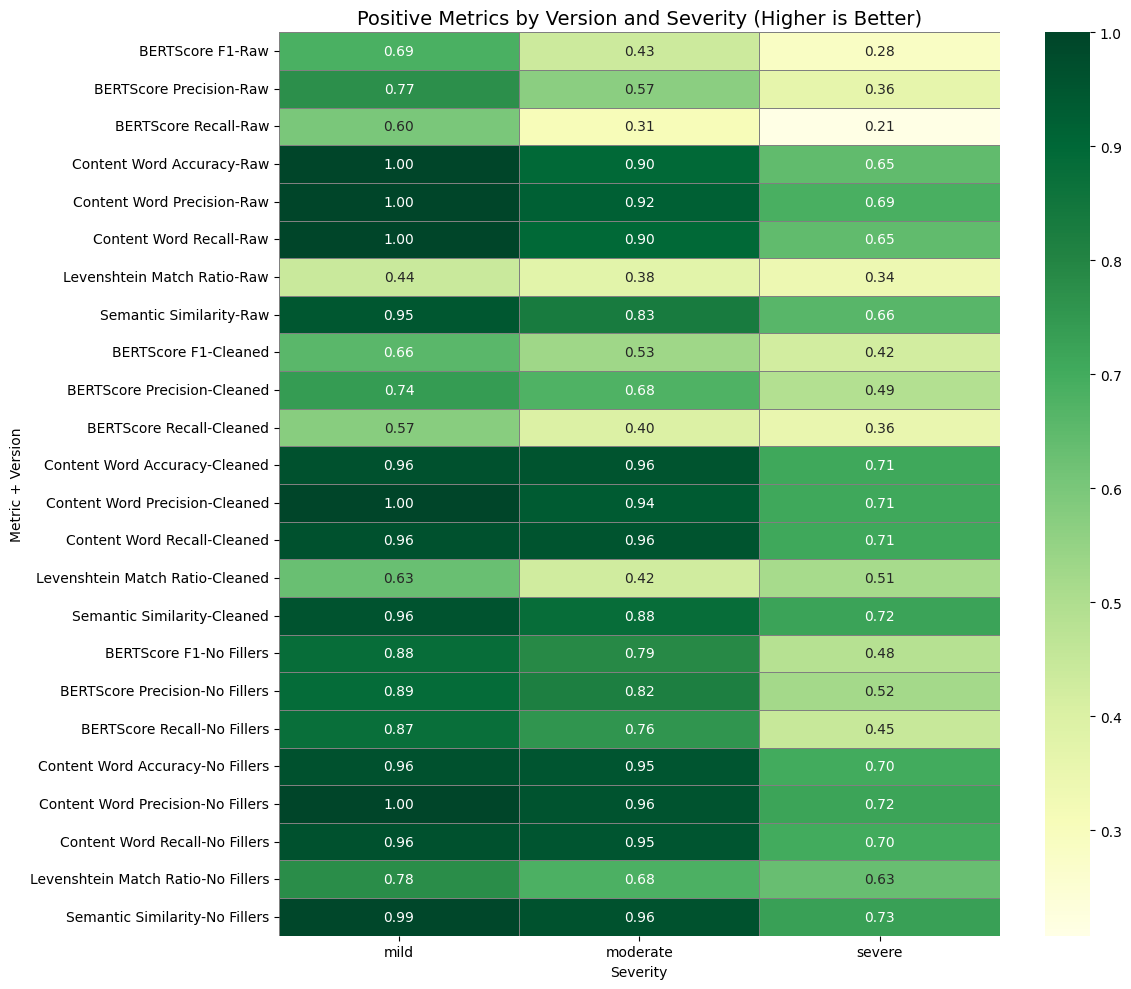

In [23]:
# Convert MultiIndex into columns
positive_df = summary_table.copy().loc[
    summary_table.index.get_level_values("Metric").isin(positive_metrics)
].reset_index()

# Sort version order as categorical
version_order = ["Raw", "Cleaned", "No Fillers"]
positive_df["Version"] = pd.Categorical(positive_df["Version"], categories=version_order, ordered=True)

# Sort first by Version, then by Metric
positive_df = positive_df.sort_values(["Version", "Metric"])

# Set MultiIndex again
positive_df = positive_df.set_index(["Metric", "Version"])

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    positive_df,
    annot=True,
    fmt=".2f",
    cmap="YlGn",
    linewidths=0.5,
    linecolor='gray'
)
plt.title("Positive Metrics by Version and Severity (Higher is Better)", fontsize=14)
plt.xlabel("Severity")
plt.ylabel("Metric + Version")
plt.tight_layout()
plt.show()

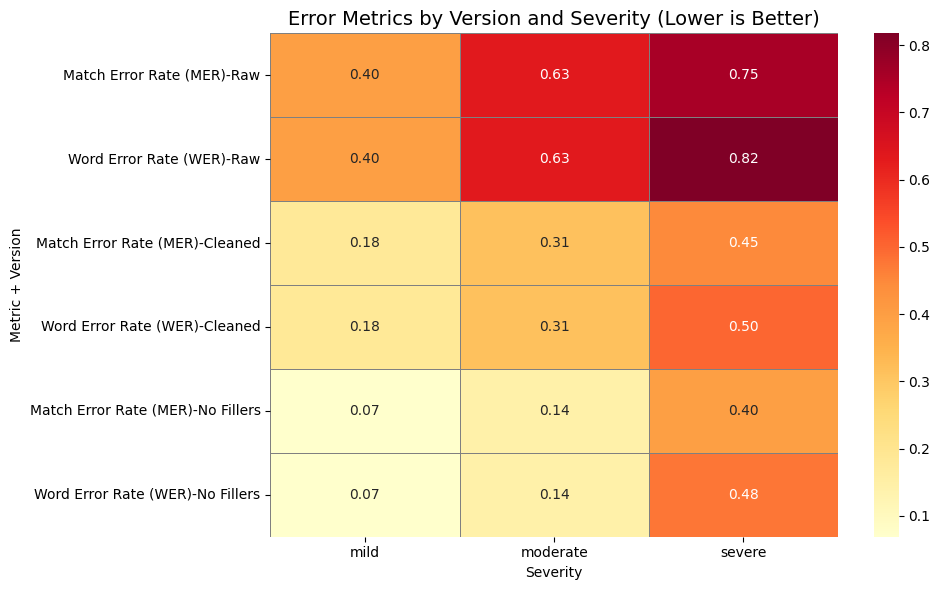

In [25]:
# Step 1: Define your error metrics
error_metrics = [
    "Word Error Rate (WER)",
    "Match Error Rate (MER)"
]

# Step 2: Filter and reset index
error_df = summary_table.copy().loc[
    summary_table.index.get_level_values("Metric").isin(error_metrics)
].reset_index()

# Step 3: Set version sort order
version_order = ["Raw", "Cleaned", "No Fillers"]
error_df["Version"] = pd.Categorical(error_df["Version"], categories=version_order, ordered=True)

# Step 4: Sort by version and metric
error_df = error_df.sort_values(["Version", "Metric"])

# Step 5: Set index back to (Metric, Version)
error_df = error_df.set_index(["Metric", "Version"])

# Step 6: Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    error_df,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",  # Yellow to Red (low = good, high = bad)
    linewidths=0.5,
    linecolor='gray'
)
plt.title("Error Metrics by Version and Severity (Lower is Better)", fontsize=14)
plt.xlabel("Severity")
plt.ylabel("Metric + Version")
plt.tight_layout()
plt.show()


In [28]:
# 2. Select only No Fillers version (best-case version)
df_nf = df_long[df_long["Version"] == "No Fillers"].copy()

# 3. Normalize all scores (0–1) per metric
from sklearn.preprocessing import MinMaxScaler

# Pivot to wide format
df_nf_wide = df_nf.pivot(index="Video", columns="Metric", values="Score")

# Normalize and invert errors
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df_nf_wide), 
                             columns=df_nf_wide.columns,
                             index=df_nf_wide.index)

# Invert error metrics so higher = better
df_normalized[error_metrics] = 1 - df_normalized[error_metrics]

# 4. Compute composite score
df_normalized["Composite Score"] = df_normalized.mean(axis=1)

# 5. Sort and print best/worst
best_video = df_normalized["Composite Score"].sort_values(ascending=False).head(1)
worst_video = df_normalized["Composite Score"].sort_values(ascending=False).tail(1)

print("Top Performing Video (No Fillers):")
print(best_video)

print("\nWorst Performing Video (No Fillers):")
print(worst_video)

Top Performing Video (No Fillers):
Video
metrics_13    1.0
Name: Composite Score, dtype: float64

Worst Performing Video (No Fillers):
Video
metrics_2    0.097651
Name: Composite Score, dtype: float64


In [30]:
df_normalized

Metric,BERTScore F1,BERTScore Precision,BERTScore Recall,Content Word Accuracy,Content Word Precision,Content Word Recall,Levenshtein Match Ratio,Match Error Rate (MER),Semantic Similarity,Word Error Rate (WER),Composite Score
Video,,,,,,,,,,,
metrics_1,0.757794,0.777778,0.791873,0.81625,0.804571,0.81625,0.000000,0.797015,0.888724,8.814879e-01,0.733174
metrics_10,0.733813,0.808706,0.726462,1.00000,1.000000,1.00000,0.725753,0.808955,0.937685,8.892734e-01,0.863065
metrics_11,0.711031,0.805269,0.692765,0.93625,1.000000,0.93625,0.929766,0.798507,0.949555,8.806228e-01,0.864002
metrics_12,0.824940,0.840779,0.848365,0.87500,1.000000,0.87500,0.908584,0.794030,0.903561,8.737024e-01,0.874396
metrics_13,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000e+00,1.000000
metrics_2,0.123501,0.210767,0.232904,0.00000,0.000000,0.00000,0.020067,0.000000,0.000000,3.892734e-01,0.097651
metrics_3,0.025180,0.309278,0.000000,0.58375,0.771429,0.58375,0.664437,0.147761,0.443620,5.060554e-01,0.403526
metrics_4,0.000000,0.000000,0.211100,0.58375,0.314286,0.58375,0.497213,0.070149,0.152819,1.110223e-16,0.241307
metrics_5,0.570743,0.660939,0.584737,0.61000,0.824000,0.61000,0.881828,0.614925,0.805638,7.768166e-01,0.693963


C:\Users\Мария\AppData\Local\Temp\ipykernel_18136\1841980541.py:34: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\Мария\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


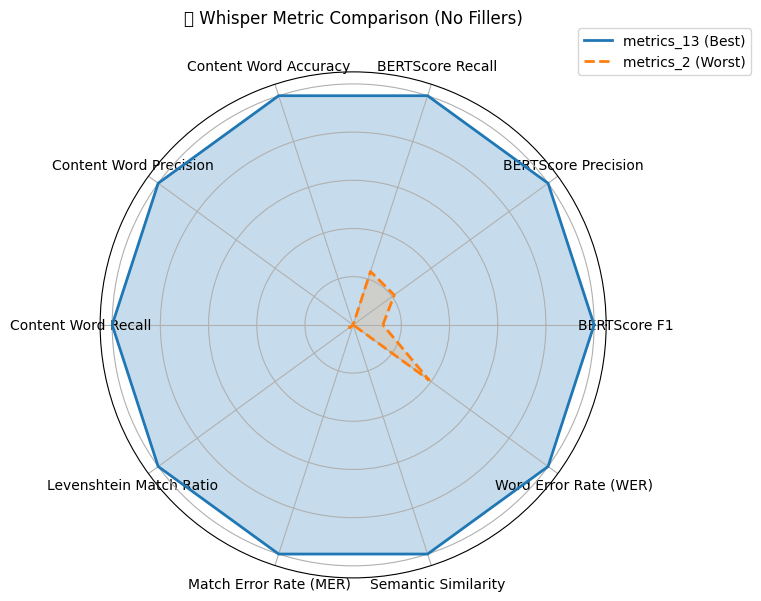

In [34]:
# Correct way to get the video IDs (index labels)
best_video = df_normalized["Composite Score"].sort_values(ascending=False).index[0]
worst_video = df_normalized["Composite Score"].sort_values(ascending=True).index[0]
 # 2. Metrics (excluding Composite Score)
metrics = [col for col in df_normalized.columns if col != "Composite Score"]

# 3. Extract values
best_scores = df_normalized.loc[best_video, metrics].values.tolist()
worst_scores = df_normalized.loc[worst_video, metrics].values.tolist()

# 4. Radar chart setup
num_vars = len(metrics)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

best_scores += best_scores[:1]
worst_scores += worst_scores[:1]

# 5. Plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, best_scores, label=f"{best_video} (Best)", linewidth=2)
ax.fill(angles, best_scores, alpha=0.25)

ax.plot(angles, worst_scores, label=f"{worst_video} (Worst)", linestyle='dashed', linewidth=2)
ax.fill(angles, worst_scores, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=10)
ax.set_yticklabels([])  # Hide radial grid labels
ax.set_title("📊 Whisper Metric Comparison (No Fillers)", y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()